# Precipitation Model Testing Using ERA5 Data

This Jupyter Notebook tests a precipitation model using ERA5 reanalysis data as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature

- **Atmospheric Profile Inputs** (from ERA5 Pressure Levels):
  - Temperature at pressure levels
  - Specific humidity at pressure levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **ERA5 Single Levels** (ECMWF): for 2m temperature, dew point, and surface pressure  
- **ERA5 Pressure Levels** (ECMWF): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_era_data.ipynb

## Packages

In [1]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh
import profiles_and_cloud_heights as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
import GB84_eqs # import f as flux, rho_m
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the data

Choose the time interval for which the model is to be run.

In [2]:
#time to check
slice_str = "2024-07-01T00:00:00, 2024-07-03T23:59:00"
slice_tuple = tuple(slice_str.split(", "))


The input data used in this model consist of a combined dataset derived from **ERA5 surface values** and **ERA5 atmospheric profiles**.

- **Surface variables** include:
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature
  - Specific humidity at the surface

- **Atmospheric profile variables** include:
  - Temperature at multiple pressure levels
  - Pressure levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [3]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

In [4]:
data_era

<xarray.Dataset> Size: 44kB
Dimensions:                (valid_time: 72, level: 24)
Coordinates:
    latitude               float64 8B ...
    longitude              float64 8B ...
  * valid_time             (valid_time) datetime64[ns] 576B 2024-07-01 ... 20...
    number                 int64 8B ...
    expver                 (valid_time) <U4 1kB ...
  * level                  (level) float64 192B 1.014e+05 1e+05 ... 2e+04
Data variables:
    temperature            (valid_time, level) float32 7kB ...
    pressure               (valid_time, level) float64 14kB ...
    height                 (valid_time, level) float64 14kB ...
    specific_humidity      (valid_time, level) float32 7kB ...
    dew_point_temperature  (valid_time) float32 288B ...

Storing the time values and the timestep.

In [5]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [6]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance and/or as inputs to the Kalman filter.

In [7]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='1H').mean()

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [8]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to include the LCL explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [9]:
T_arr = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
my_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [10]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

theta_type = 'GB84'       #choose which approach to follow for the conserved potential temperature

for i in range(0,T_air.shape[0]):
    #print(i)
    #calculating the profiles
    T_arr[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel[i], p_new[i], Z_new[i], lcl_index[i], my_temp_new[i], q_v_new[i] = interp.insert_lcl_values(T_arr[i,:],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel[i,:],int(lcl_index[i]),theta_type=theta_type)

a 284.61406798884565
a 284.15815236732294
a 283.79019758732215
a 283.6673099998139
a 284.2290412494471
a 282.7031524025673
a 282.46440670757556
a 283.44449418416195
a 282.5031144271461
a 282.3269650940358
a 282.2971276034117
a 282.93263346912613
a 283.9521898926921
a 283.91509941834187
a 285.5484402158973
a 286.7733301290268
a 287.0367215638521
a 286.97803255520734
a 286.2917202271957
a 285.97338625718595
a 283.7965205404353
a 282.76988630144547
a 280.8353737584541
a 280.4055953678181
a 280.4085826612683
a 281.13799711892034
a 282.0020438329395
a 282.5278797385937
a 282.66038395411863
a 282.58743707980625
a 283.064385535021
a 283.76183870606815
a 285.39147613798445
a 284.50238659405454
a 281.78867056352067
a 282.50485039719433
a 283.84521749714617
a 285.282512890712


Calculate the environmental virtual temperature profiles

In [11]:
T_v_env = my_temp_new*(1+0.61*q_v_new)  #no liquid water in the environmental air

### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [12]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [13]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel[i])

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [14]:
#import updraft_emmanuel

w_parcel_max = np.zeros(rows)

for i in range(0,rows):
    #print(i)
    if Z_t[i] == 0 or Z_c[i] <= 1:
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z[i],T_v_moist[i],T_v_env[i],LFC_index[i,1],top_index)

### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [15]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)
rho_arr = np.zeros(rows)

for i in range(0,rows):
    print(i)
    if Z_t[i] == 0 :
        top_index = 0
    else:
         top_index = np.argmax((Z_t[i] - Z_new[i]) <= 0)

    w_avg = w_parcel_max[i]/2
    rho = GB84_eqs.rho_m(T_s[i],my_temp_new[i,min(top_index,cols-1)],p_s[i],p_t[i])
    rho_arr[i] = rho
    if w_parcel_max[i] == 0:
        # no convection == no flux
        f_arr[i] = 0
    else:
        f_arr[i] = GB84_eqs.calculate_liquid_water_flux(T_d[i],p_new[i,0],p_t[i],my_temp_new[i,min(top_index,cols-1)],rho,w_avg)

    if i<rows-1:
        if X[i]/Z_c[i] > 2.5e-3:        #capping the LWC values so that they don't abnormally high
            X[i] = 2.5e-3*Z_c[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconversion_rate(X[i],Z_c[i],thresh)*dt_seconds[i]# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])      #ensuring that the LWC is non-negative

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71


### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [16]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(my_temp_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

In [17]:
indexes = np.where(f_arr>0)
np.mean(f_arr[indexes])

0.031054323167803353

In [18]:
np.mean(Z_c[indexes])

2193.8790029194383

## Visualizing the outputs

#### Rainfall rate

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

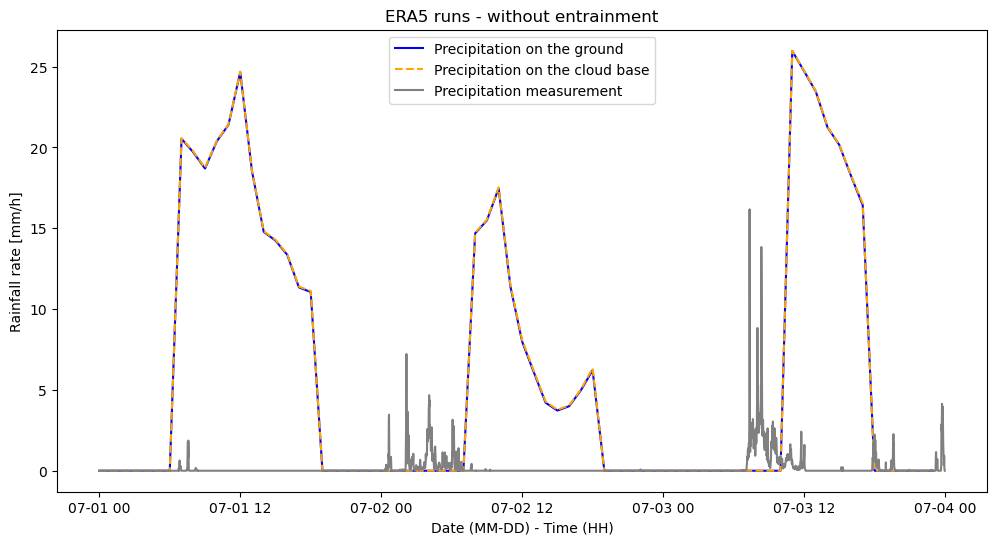

In [19]:
plt.figure(figsize=(12,6))
plt.title('ERA5 runs - without entrainment')
plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
plt.plot(time,R*3600,color='orange',linestyle='--',label='Precipitation on the cloud base')
plt.plot(rain_rate.time,rain_rate,color='gray',label='Precipitation measurement')
plt.legend()
plt.ylabel('Rainfall rate [mm/h]')
plt.xlabel('Date (MM-DD) - Time (HH)')

#### Virtual Temperature profiles at different times

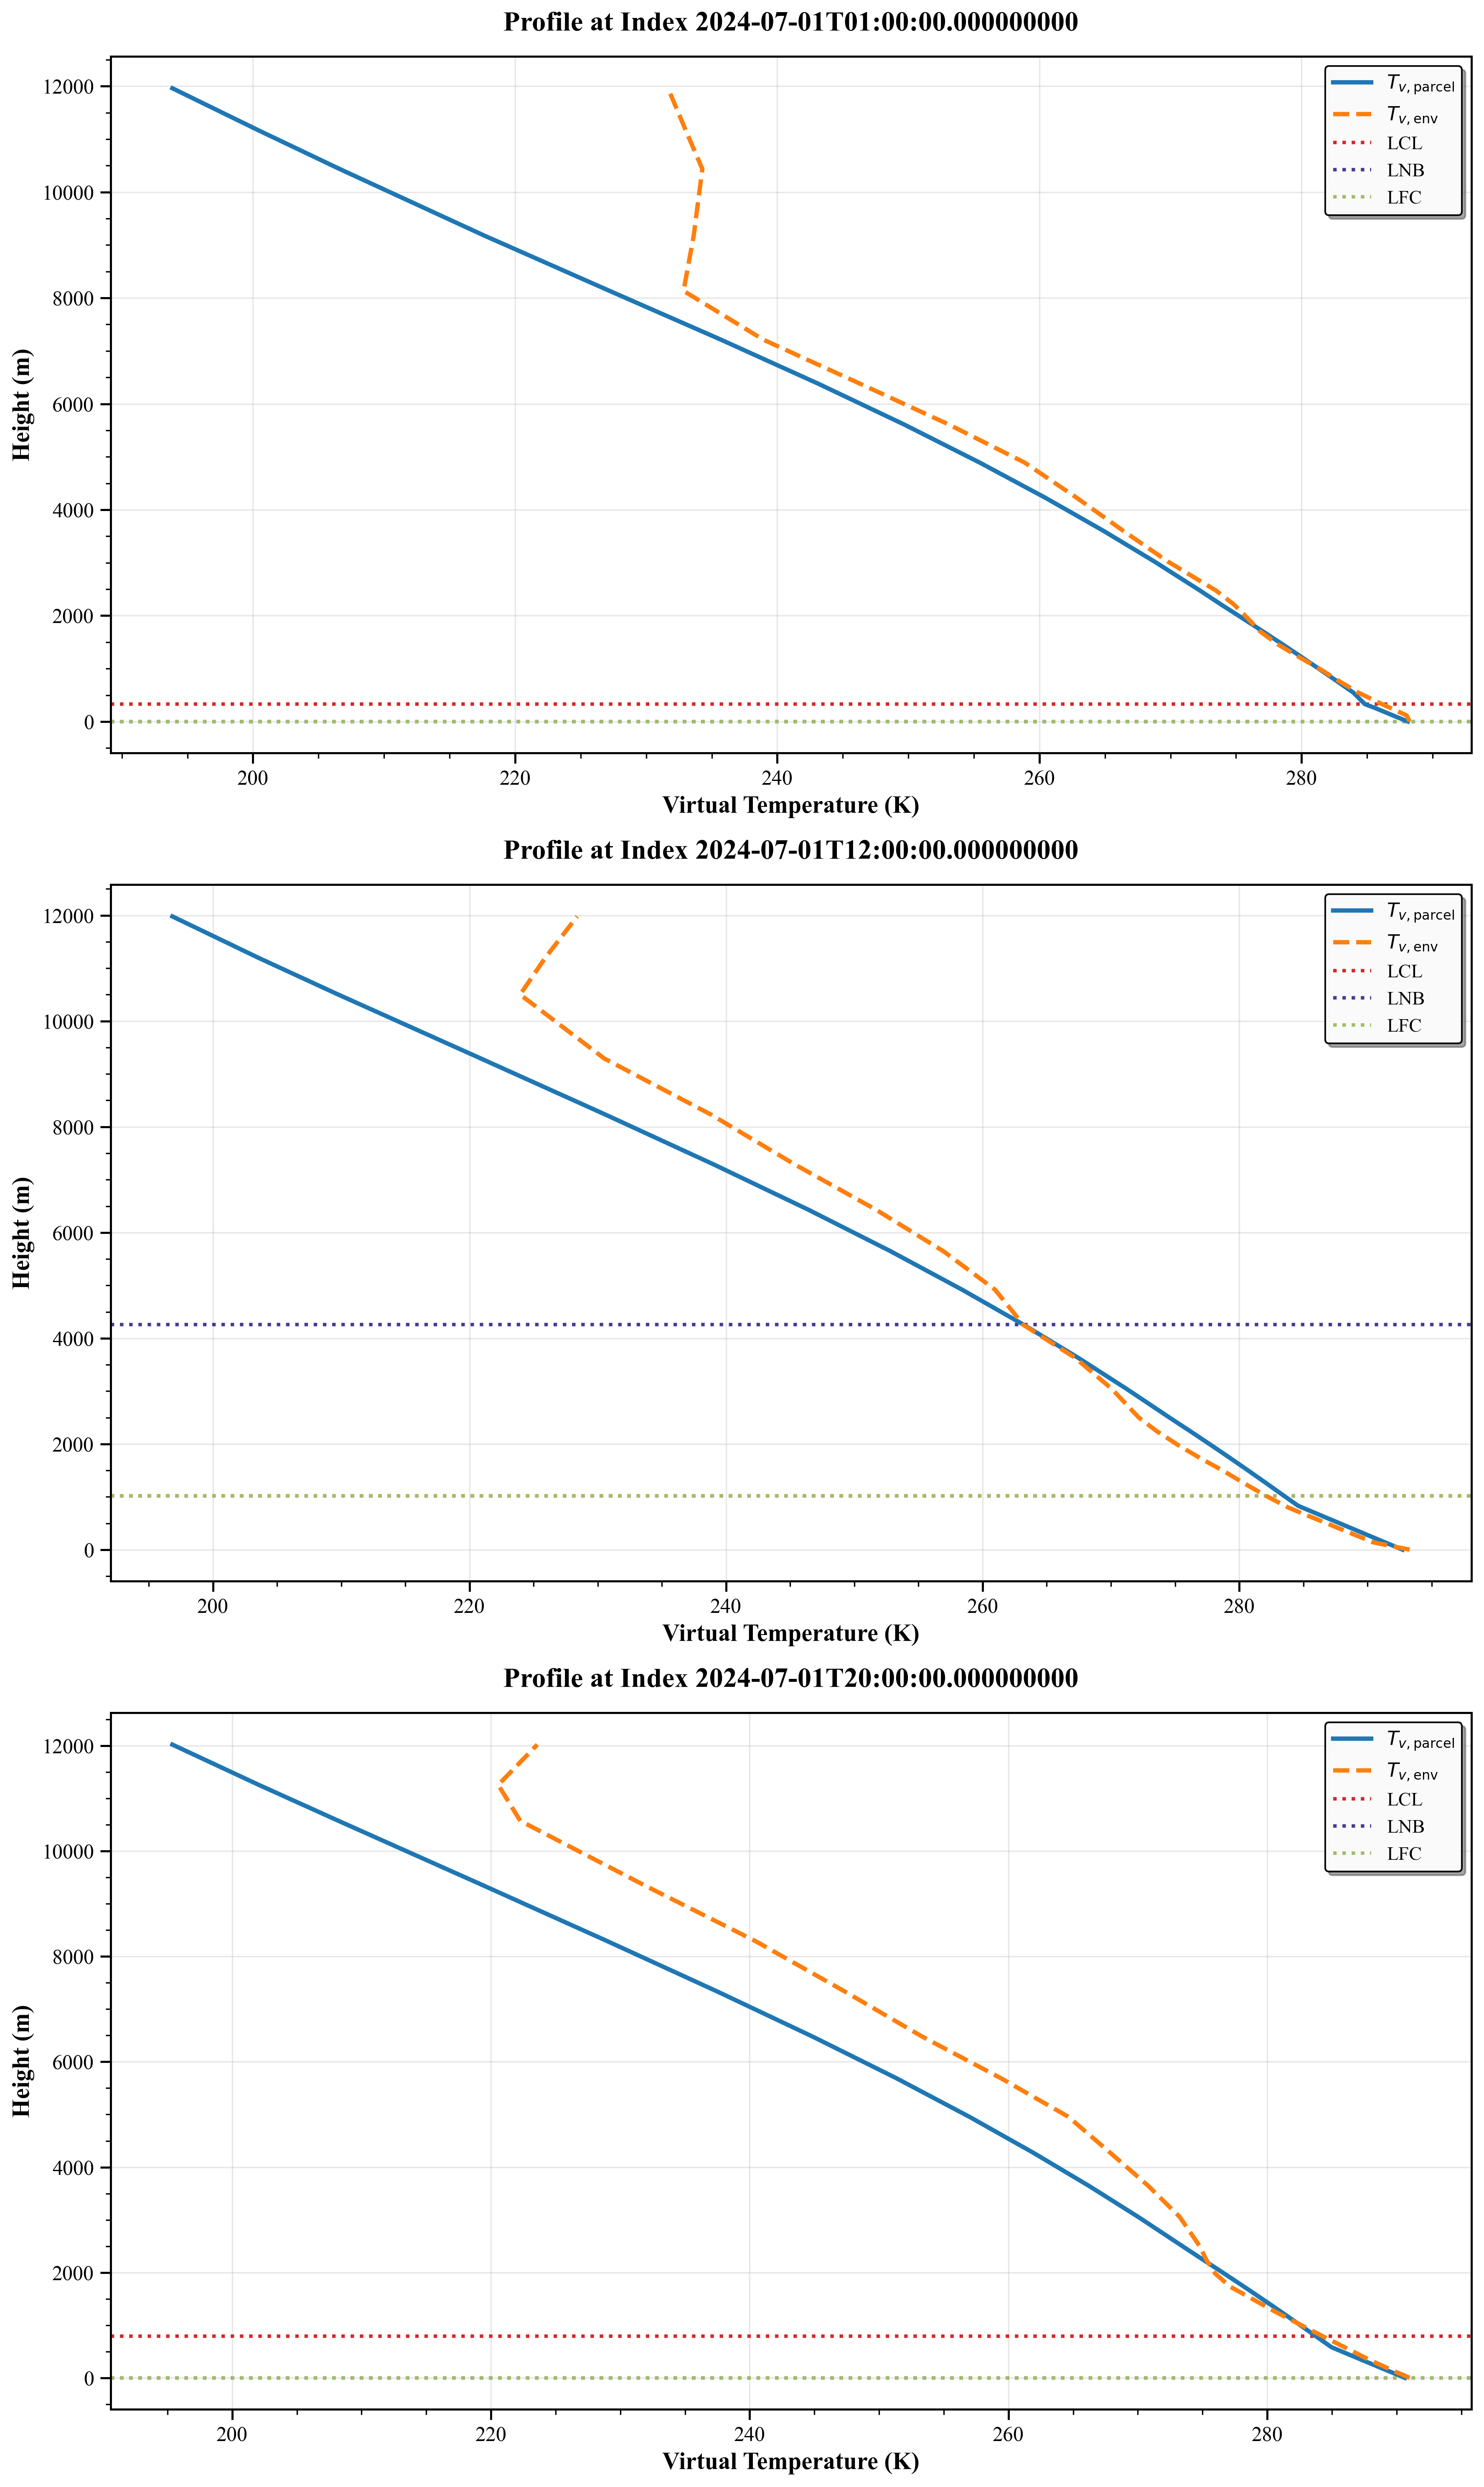

In [20]:
import matplotlib.pyplot as plt

# Set publication-quality style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1
})

# Create 4-panel subplot
fig, axes = plt.subplots(3, 1, figsize=(12, 20))
axes = axes.flatten()

# Define which indices to plot
indices_to_plot = [1, 12, 20]  # Adjust based on your dataset

for i, ax in enumerate(axes):
    index_2 = indices_to_plot[i]

    # Plot virtual temperature of parcel (moist)
    ax.plot(T_v_moist[index_2], Z_new[index_2], 
            label=r'$T_{v,\mathrm{parcel}}$', color='#1f77b4', linewidth=2.5, zorder=3)

    # Plot environmental virtual temperature
    ax.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2],
            label=r'$T_{v,\mathrm{env}}$', color='#ff7f0e', linestyle='--', linewidth=2.5, zorder=3)

    # Add horizontal lines for LCL, LNB, and LFC
    ax.axhline(y=Z[index_2, int(lcl_index[index_2])], 
               color='#d62728', linestyle=':', linewidth=2, label='LCL', alpha=1, zorder=2)
    ax.axhline(y=Z_t[index_2], 
               color="#1d087a", linestyle=':', linewidth=2, label='LNB', alpha=0.8, zorder=2)
    ax.axhline(y=Z[index_2, int(LFC_index[index_2, 1])], 
               color="#9fbd67ff", linestyle=':', linewidth=2, label='LFC', alpha=1, zorder=2)

    # Labels and title
    ax.set_xlabel('Virtual Temperature (K)', fontweight='bold')
    ax.set_ylabel('Height (m)', fontweight='bold')
    ax.set_title(f'Profile at Index {time[index_2].values}', fontweight='bold', pad=15)

    # Styling
    legend = ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True,
                       framealpha=0.95, edgecolor='black', facecolor='white')
    ax.grid(True, alpha=0.3, linewidth=0.8, zorder=1)
    ax.set_axisbelow(True)
    ax.minorticks_on()
    ax.tick_params(which='major', length=6, width=1.2)
    ax.tick_params(which='minor', length=3, width=0.8)

    # Optional: Set axis limits
    #ax.set_xlim(240, 300)
    #ax.set_ylim(0, 4000)

# Layout adjustment
plt.tight_layout()

# Save the figure
#plt.savefig('virtual_temp_profiles_4panel.png')
#plt.savefig('virtual_temp_profiles_4panel.pdf')

plt.show()

# Reset style
plt.rcParams.update(plt.rcParamsDefault)


In [21]:
import matplotlib.pyplot as plt


# Set publication-quality style
plt.style.use('default')
plt.rcParams.update({
    'font.size': 12,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'axes.linewidth': 1.2,
    'axes.labelsize': 14,
    'axes.titlesize': 14,  # Slightly smaller for better proportion
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'axes.spines.top': False,    # Remove top spine
    'axes.spines.right': False,  # Remove right spine
})

# Create 3-panel subplot with better spacing
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Wider for better readability

# Define which indices to plot
indices_to_plot = [1, 12, 20]

# Panel labels for publication quality
panel_labels = ['(a)', '(b)', '(c)']

for i, ax in enumerate(axes):
    index_2 = indices_to_plot[i]
    
    # Plot virtual temperature of parcel (moist) with area fill
    parcel_line = ax.plot(T_v_moist[index_2], Z_new[index_2],
                         label=r'$T_{v,\mathrm{parcel}}$', color='#1f77b4', 
                         linewidth=3, zorder=4, alpha=0.9)
    
    # Plot environmental virtual temperature
    env_line = ax.plot(my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]), Z_new[index_2],
                      label=r'$T_{v,\mathrm{env}}$', color='#ff7f0e', 
                      linestyle='--', linewidth=3, zorder=4, alpha=0.9)
    
    # Add subtle shading between curves to show CAPE region
    #ax.fill_betweenx(Z_new[index_2], 
                     #T_v_moist[index_2], 
                     #my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2]),
                     #where=(T_v_moist[index_2] > my_temp_new[index_2] * (1 + 0.61 * q_v_new[index_2])),
                     #color='lightblue', alpha=0.3, label='CAPE region', zorder=1)
    
    # Add horizontal lines for LCL and LFC with offset when they coincide
    lcl_height = Z[index_2, int(lcl_index[index_2])]
    lfc_height = Z[index_2, int(LFC_index[index_2, 1])]
    
    # Check if LCL and LFC are very close (within 50m)
    if abs(lcl_height - lfc_height) < 50:
        # Offset the visual lines slightly for clarity
        lcl_line = ax.axhline(y=lcl_height - 25,
                             color='#d62728', linestyle='-.', linewidth=2.5, 
                             label='LCL', alpha=0.8, zorder=3)
        
        lfc_line = ax.axhline(y=lfc_height + 25,
                             color='#2ca02c', linestyle='-.', linewidth=2.5, 
                             label='LFC', alpha=0.8, zorder=3)
        
        # Add text annotations to clarify they're actually coincident
        ax.text(0.98, 0.5, 'LCL ≈ LFC', transform=ax.transAxes, 
                fontsize=10, ha='right', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    else:
        # Normal case - lines at actual heights
        lcl_line = ax.axhline(y=lcl_height,
                             color='#d62728', linestyle='-.', linewidth=2.5, 
                             label='LCL', alpha=0.8, zorder=3)
        
        lfc_line = ax.axhline(y=lfc_height,
                             color='#2ca02c', linestyle='-.', linewidth=2.5, 
                             label='LFC', alpha=0.8, zorder=3)
    
    # Add panel label
    ax.text(0.02, 0.98, panel_labels[i], transform=ax.transAxes, 
            fontsize=16, fontweight='bold', va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    # Labels and title with better formatting
    ax.set_xlabel('Virtual Temperature (K)', fontweight='bold')
    if i == 0:  # Only leftmost panel gets y-label
        ax.set_ylabel('Height (m)', fontweight='bold')
    
    # More descriptive titles with time information (hours only)
    time_hours = pd.to_datetime(time[index_2].values).strftime('%Y-%m-%d %H:%M')
    ax.set_title(f'Time: {time_hours}', fontweight='bold', pad=20)
    
    # Enhanced legend with better positioning
    legend = ax.legend(loc='upper right', frameon=True, fancybox=True, shadow=True,
                      framealpha=0.95, edgecolor='black', facecolor='white',
                      borderpad=0.8, handletextpad=0.5)
    
    # Professional grid
    ax.grid(True, alpha=0.25, linewidth=0.8, zorder=1, linestyle='-')
    ax.set_axisbelow(True)
    
    # Enhanced tick formatting
    ax.minorticks_on()
    ax.tick_params(which='major', length=6, width=1.2, direction='out')
    ax.tick_params(which='minor', length=3, width=0.8, direction='out')
    
    # Set consistent axis limits with better ranges
    ax.set_xlim(240, 300)
    ax.set_ylim(0, 4000)
    
    # Add temperature grid lines at key intervals
    temp_ticks = np.arange(245, 300, 10)
    ax.set_xticks(temp_ticks)
    
    # Height grid lines at key intervals
    height_ticks = np.arange(0, 4500, 500)
    ax.set_yticks(height_ticks)

# Add overall figure title
fig.suptitle('Virtual Temperature Profiles for different dates', 
             fontsize=16, fontweight='bold', y=0.96)

# Better layout with more space between panels
plt.tight_layout()
plt.subplots_adjust(top=0.8, wspace=0.25)  # More space for suptitle and between panels


plt.show()

# Reset style
plt.rcParams.update(plt.rcParamsDefault)

NameError: name 'pd' is not defined

In [ ]:
T_v_env[20] - T_v_moist[20]

array([ 0.35655214,  0.41189973,  0.60985342,  1.04881023,  0.90239731,
        0.52088296,  0.04122851, -0.43371862, -0.75251931, -1.07181985,
       -0.693873  ,  0.23101027,  1.34440255,  3.21488229,  4.6003845 ,
        5.96551709,  7.66737113,  8.10157505,  8.49104801,  9.89781718,
       11.49731919, 12.52734565, 14.08799881, 18.54357525, 28.24922472])

#### Cloud top and base

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Cloud altitudes ERA5')
plt.plot(time,Z_t,color='red',linestyle='--',label='Cloud top')
plt.plot(time,Z_new[np.arange(Z_new.shape[0]),lcl_index.astype(int)],color='blue',linestyle='--',label='LCL')
plt.ylabel('Height (m)')
plt.xlabel('Time')
plt.legend()

In [ ]:
plt.plot(T_v_moist[2],Z_new[2])
plt.plot(T_v_env[2],Z_new[2])

In [ ]:
data = np.load('parcel_data.npz')
temp_parcel_2 = data['temp_parcel']
temp_env_2 = data['temp_env']
q_v_parcel_2 = data['q_v_parcel']
Z_2 = data['Z']

In [ ]:
import pandas as pd
time_str = pd.to_datetime(time[2].values).strftime('%Y-%m-%d %H:%M')
plt.title(f'ERA5 runs downscaled - time {time_str}')
plt.plot(temp_parcel[2], Z_new[2], label='$T_{parcel}$', color='blue')
plt.plot(my_temp_new[2], Z_new[2], label='$T_{env}$', color='red', linestyle='--')
plt.plot(temp_env_2, Z_2, label='$T_{env}$', color='green', linestyle='--')
plt.plot(temp_parcel_2, Z_2, label='$T_{parcel}$', color='orange')
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend()

In [ ]:
Z_2

array([2.00000000e+00, 5.09402902e+01, 2.01248254e+02, 2.68029063e+02,
       4.89895169e+02, 7.17040816e+02, 9.49498166e+02, 1.18732581e+03,
       1.43065968e+03, 1.67971739e+03, 1.93486966e+03, 2.19643854e+03,
       2.46492068e+03, 3.02486209e+03, 3.61819994e+03, 4.24934112e+03,
       4.92455238e+03, 5.65080556e+03, 6.43759845e+03, 7.30217474e+03,
       8.26220663e+03, 9.33419005e+03, 1.05553253e+04, 1.12493048e+04,
       1.20260969e+04])

In [ ]:
import pandas as pd
time_str = pd.to_datetime(time[2].values).strftime('%Y-%m-%d %H:%M')
plt.title(f'ERA5 runs downscaled - time {time_str}')
plt.plot(q_v_new[2], Z_new[2], label='$q_{env}$', color='blue')
plt.plot(q_v_parcel[2], Z_new[2], label='$q_{parcel}$', color='red', linestyle='--')
plt.plot(q_v_parcel_2, Z_2, label='$q_{parcel_{downscaled}}$', color='green', linestyle='--')
plt.xlabel('Temperature (K)')
plt.ylabel('Height (m)')
plt.legend()

#### Updraft velocity

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,w_parcel_max/2,linewidth=0.7)
plt.ylabel('Average Updraft velocity (m/s)')
plt.xlabel(('Date (MM-DD) - Time (HH)'))

Text(0.5, 0, 'Date (MM-DD) - Time (HH)')

#### LWC and LWP(state)

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,X/Z_c*1000)
plt.ylabel('Cloud water content [g/m3]')
plt.xlabel('Time')
plt.ylim(0,10)

(0.0, 10.0)

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(time,X)
plt.xlabel('Time')
plt.ylabel('Cloud water content [kg/m2]')

Text(0, 0.5, 'Cloud water content [kg/m2]')

#### Size distribution

In [ ]:
D = np.linspace(0.001,0.6,1000)
N = 6e4 * np.exp(3.2 * mu_result)* D**(mu_result)*np.exp(-Lambda_result*D)#plt.ylim(0,100)

plt.figure(figsize=(8,4))
plt.title(f'R = {R[i] * 3600:.2f} mm/hr')
plt.plot(D*10,N)
plt.axvline(x=D_critical*1000,color='r',linestyle='--',label='Critical diameter for evaporation')
plt.xlabel('Diameter (mm)')
plt.ylabel('n(D) [m-3]')
plt.legend()